# RACMO 2km daily data from 1979-2025 (t2m, precip, snowmelt and ff10m)

Latest RACMO data to use (as of June 2026). 

Given to use by Brice Noel (Noël et al. (2023)). 

This notebook loads a spatial subset around Flask. 

This subsetted was done with code in /cryocloud_racmosubsetting/ and performed on cryocloud. 


## Info from Brice Noel:

The data consist of:
AIS: RACMO2.3p2 at 2 km (statistically downscaled from the output of RACMO2.3p2 at 27km):
- Daily total precipitation and total melt expressed in mm w.e. or kg/m2 per month covering the whole AIS and floating ice shelves for 1 Jan 1979 - 31 Dec 2025.
- Daily mean 2 m air temperature (K) for the same period.
- Daily mean 10 m wind speed (ff10m, m/s) for the same period. NB: This is an experimental downscaled wind speed, if that does not work for you, we can provide raw RACMO2 data.
- Mask file including: lon/lat, AIS and ice shelves masks and topography from the REMA DEM upscaled to 2 km.

Forcing: The data set is based on ERA5 (1979-2025) reanalyses.

Reference: The data set is discussed in Noël et al. (2023).

Projection: The projection used for statistical downscaling is Polar Stereographic South (EPSG:3031) and the resolution is exactly 2 km x 2 km. 


In [2]:
import xarray as xr
import hvplot.xarray
import matplotlib.pyplot as plt
import pandas as pd

## open one manually downloaded 

In [43]:
ds_1 = xr.open_dataset('/Users/jkingslake/Documents/data/snowmelt.1979_AMJ.BN_RACMO2.3p2_ANT27_ERA5_3h.AIS.2km.DD.nc')
ds_1

<xarray.Dataset> Size: 2GB
Dimensions:       (time: 91, x: 2778, y: 2303)
Coordinates:
  * time          (time) datetime64[ns] 728B 1979-04-01 ... 1979-06-30
  * x             (x) float32 11kB -2.731e+06 -2.729e+06 ... 2.821e+06 2.823e+06
  * y             (y) float32 9kB -2.232e+06 -2.23e+06 ... 2.37e+06 2.372e+06
Data variables:
    snowmeltcorr  (time, y, x) float32 2GB ...
Attributes:
    CDI:          Climate Data Interface version 2.4.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  IMAU (Brice Noel)
    title:        Daily mean snowmelt field at 2km (RACMO2.3p2) ERA
    grid:         Map Projection: Antarctic Polar Stereographic EPSG3031 - Ma...
    history:      Thu Nov 14 13:23:25 2024: cdo -f nc4 -z zip_5 copy snowmelt...
    netcdf:       4.7.4 of Apr 18 2020 10:56:44 $
    CDO:          Climate Data Operators version 2.4.4 (https://mpimet.mpg.de...

## narrow subsetted full version

In [8]:
ds = xr.open_dataset('../../data/rcm/flask_racmo2km_rechunked.zarr')

In [9]:
ds.load()

<xarray.Dataset> Size: 59MB
Dimensions:       (time: 17167, y: 12, x: 18)
Coordinates:
  * time          (time) datetime64[ns] 137kB 1979-01-01 ... 2025-12-31
  * x             (x) float32 72B -2.383e+06 -2.381e+06 ... -2.349e+06
  * y             (y) float32 48B 1.22e+06 1.222e+06 ... 1.24e+06 1.242e+06
Data variables:
    ff10mcorr     (time, y, x) float32 15MB nan nan nan ... 1.346 1.355 1.371
    precipcorr    (time, y, x) float32 15MB 0.0 0.0 0.0 ... 0.1992 0.2109 0.2189
    snowmeltcorr  (time, y, x) float32 15MB 0.0 0.0 0.0 ... 6.937 6.921 6.929
    t2mcorr       (time, y, x) float32 15MB 267.3 268.0 268.2 ... 272.6 272.6
Attributes:
    CDI:          Climate Data Interface version 2.4.4 (https://mpimet.mpg.de...
    CDO:          Climate Data Operators version 2.4.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    grid:         Map Projection: Antarctic Polar Stereographic EPSG3031 - Ma...
    history:      Wed May 20 22:39:46 2026: cdo -f nc4 -z zip_5 copy ff10m/ff...
    institution:  IMAU (Brice Noel)
    netcdf:       4.9.0 of Jan  4 2023 16:53:07 $
    title:        Daily mean ff10m field at 2km (RACMO2.3p2 ANT27 ERA)

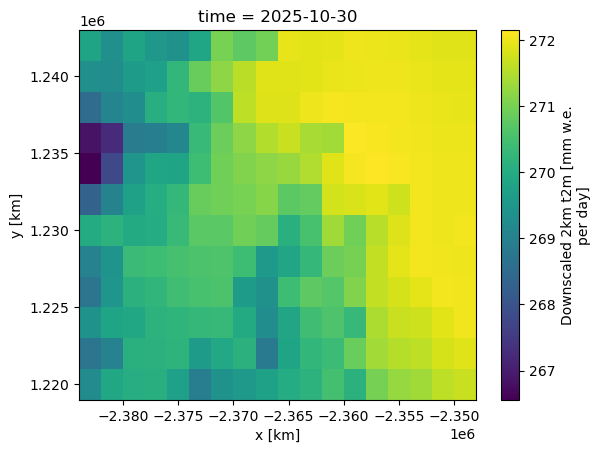

In [6]:
ds.t2mcorr.sel(time='2025-10-30', method='nearest').plot()

In [5]:
ds.precipcorr.isel(time=100).hvplot(x='x', y='y')

:Image   [x,y]   (Downscaled 2km precip)

In [4]:
ds.t2mcorr.hvplot(x='x', y='y')

BokehModel(combine_events=True, render_bundle={'docs_json': {'dab203af-89e4-46c7-a52b-2c8265c88202': {'version…

:DynamicMap   [time]
   :Image   [x,y]   (Downscaled 2km t2m)

In [59]:
pd.Timedelta(days=365/2)

Timedelta('182 days 12:00:00')

In [79]:

ds_annual = ds.sel(time=slice('1979-01-01', '2025-06-30')).resample(time='YS-JUL').sum('time').mean(['x', 'y'])
ds_annual['time'] = ds_annual.indexes['time'].shift(1, freq='YS')


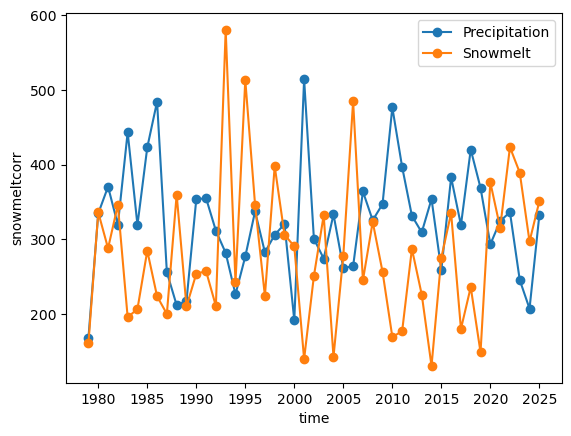

In [80]:
P_annual = ds_annual.precipcorr

M_annual = ds_annual.snowmeltcorr

P_annual.plot(marker='o', label='Precipitation')
M_annual.plot(marker='o', label='Snowmelt')
plt.legend()

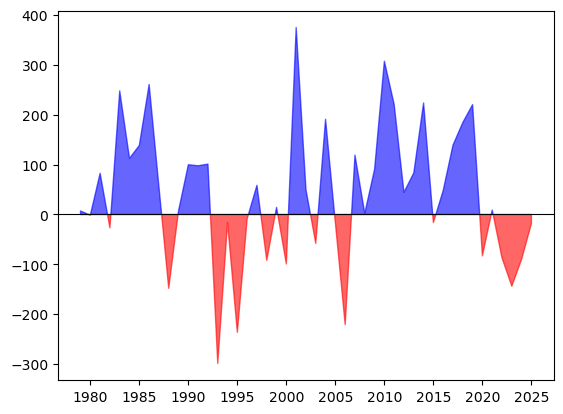

In [81]:
diff = (P_annual - M_annual)
time = diff.time.values
values = diff.values

fig, ax = plt.subplots()
ax.fill_between(time, values, where=(values >= 0), interpolate=True, color='blue',  alpha=0.6)
ax.fill_between(time, values, where=(values <= 0), interpolate=True, color='red', alpha=0.6)
ax.axhline(0, color='k', linewidth=0.8)

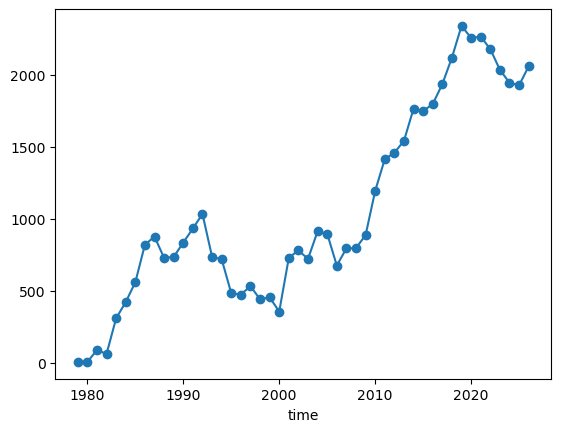

In [78]:
diff.cumsum().plot(marker='o')

## Wider subset, initially in the google bucket, but I have downloaded it to my local machine, 

In [ ]:
ds_wide = xr.open_dataset("gcs://ldeo-glaciology/temp/flask_wide_racmo2km.zarr", engine = 'zarr', chunks={})



In [ ]:
# ds_wide.to_zarr("flask_wide_racmo2km.zarr", mode='w', consolidated=True)

In [3]:
ds_wide = xr.open_dataset("flask_wide_racmo2km.zarr", engine = 'zarr')
ds_wide

<xarray.Dataset> Size: 5GB
Dimensions:       (time: 17167, y: 111, x: 158)
Coordinates:
  * time          (time) datetime64[ns] 137kB 1979-01-01 ... 2025-12-31
  * x             (x) float32 632B -2.515e+06 -2.513e+06 ... -2.201e+06
  * y             (y) float32 444B 1.09e+06 1.092e+06 ... 1.308e+06 1.31e+06
Data variables:
    ff10mcorr     (time, y, x) float32 1GB ...
    precipcorr    (time, y, x) float32 1GB ...
    snowmeltcorr  (time, y, x) float32 1GB ...
    t2mcorr       (time, y, x) float32 1GB ...
Attributes:
    CDI:          Climate Data Interface version 2.4.4 (https://mpimet.mpg.de...
    CDO:          Climate Data Operators version 2.4.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    grid:         Map Projection: Antarctic Polar Stereographic EPSG3031 - Ma...
    history:      Wed May 20 22:39:46 2026: cdo -f nc4 -z zip_5 copy ff10m/ff...
    institution:  IMAU (Brice Noel)
    netcdf:       4.9.0 of Jan  4 2023 16:53:07 $
    title:        Daily mean ff10m field at 2km (RACMO2.3p2 ANT27 ERA)

In [4]:
ds_wide.load()

<xarray.Dataset> Size: 5GB
Dimensions:       (time: 17167, y: 111, x: 158)
Coordinates:
  * time          (time) datetime64[ns] 137kB 1979-01-01 ... 2025-12-31
  * x             (x) float32 632B -2.515e+06 -2.513e+06 ... -2.201e+06
  * y             (y) float32 444B 1.09e+06 1.092e+06 ... 1.308e+06 1.31e+06
Data variables:
    ff10mcorr     (time, y, x) float32 1GB nan nan nan nan ... 0.0 0.0 0.0 0.0
    precipcorr    (time, y, x) float32 1GB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    snowmeltcorr  (time, y, x) float32 1GB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    t2mcorr       (time, y, x) float32 1GB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    CDI:          Climate Data Interface version 2.4.4 (https://mpimet.mpg.de...
    CDO:          Climate Data Operators version 2.4.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    grid:         Map Projection: Antarctic Polar Stereographic EPSG3031 - Ma...
    history:      Wed May 20 22:39:46 2026: cdo -f nc4 -z zip_5 copy ff10m/ff...
    institution:  IMAU (Brice Noel)
    netcdf:       4.9.0 of Jan  4 2023 16:53:07 $
    title:        Daily mean ff10m field at 2km (RACMO2.3p2 ANT27 ERA)

In [12]:
ds_wide.mean()

<xarray.Dataset> Size: 16B
Dimensions:       ()
Data variables:
    ff10mcorr     float32 4B 2.951
    precipcorr    float32 4B 2.382
    snowmeltcorr  float32 4B 0.5364
    t2mcorr       float32 4B 189.3

In [14]:
ds_wide.precipcorr.nbytes/1e9

1.204299384

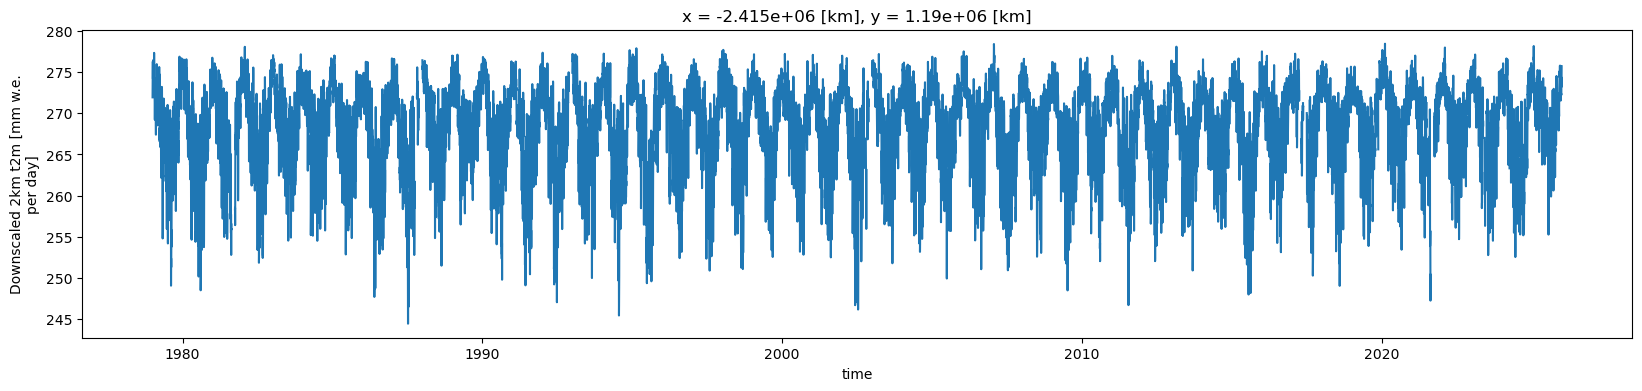

In [11]:
ds_wide.t2mcorr.isel(x=50, y=50).plot(figsize=(20, 4))